In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving clean_telco.csv to clean_telco.csv


In [3]:
telco = pd.read_csv(
    "clean_telco.csv"
)

telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print(telco.shape)

telco.info()

(7032, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null

In [5]:
telco["Churn"] = telco["Churn"].map(
    {
        "No":0,
        "Yes":1
    }
)

In [6]:
label_encoder = LabelEncoder()

for column in telco.columns:

    if telco[column].dtype == "object":

        telco[column] = label_encoder.fit_transform(
            telco[column]
        )

In [7]:
X = telco.drop(
    columns=[
        "customerID",
        "Churn"
    ]
)

y = telco["Churn"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [10]:
y_pred = rf_model.predict(
    X_test
)

In [11]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy: {accuracy:.2%}"
)


Accuracy: 78.82%


In [12]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



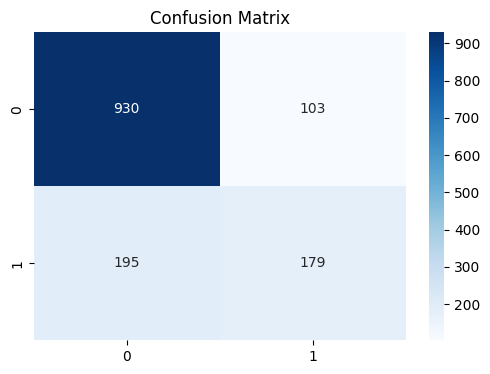

In [13]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

In [14]:
importance = pd.DataFrame(
    {
        "Feature":X.columns,
        "Importance":rf_model.feature_importances_
    }
)

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
18,TotalCharges,0.186602
17,MonthlyCharges,0.178367
4,tenure,0.155314
14,Contract,0.080190
16,PaymentMethod,0.051079
8,OnlineSecurity,0.048970
11,TechSupport,0.042888
7,InternetService,0.027614
0,gender,0.027456
9,OnlineBackup,0.026431


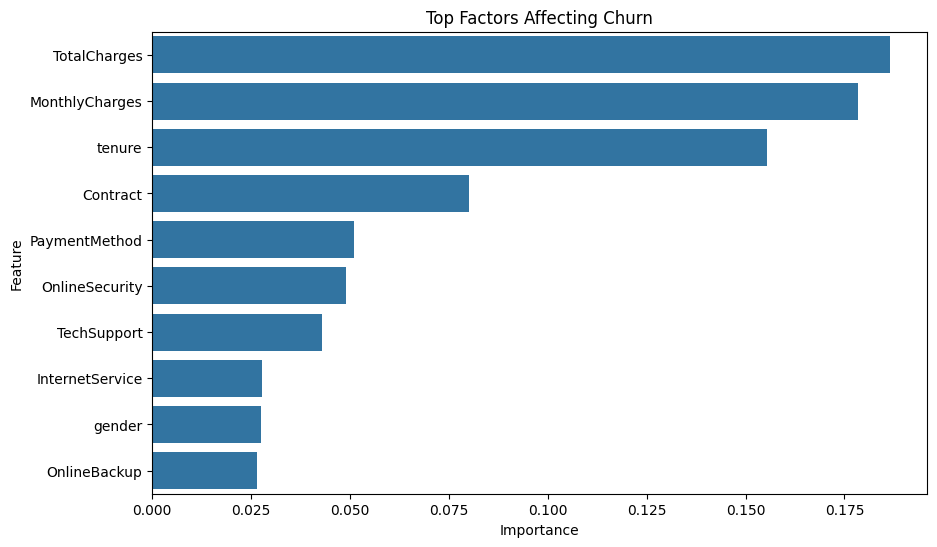

In [15]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Factors Affecting Churn"
)

plt.show()

In [16]:
telco["Churn_Probability"] = rf_model.predict_proba(X)[:,1]

at_risk = telco[
    telco["Churn_Probability"] > 0.7
]

at_risk.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Probability
2,2558,1,0,0,0,2,1,0,0,2,...,0,0,0,0,1,3,53.85,108.15,1,0.825
4,6500,0,0,0,0,2,1,0,1,0,...,0,0,0,0,1,2,70.70,151.65,1,0.845
5,6540,0,0,0,0,8,1,2,1,0,...,0,2,2,0,1,2,99.65,820.50,1,0.985
13,174,1,0,0,0,49,1,2,1,0,...,0,2,2,0,1,0,103.70,5036.30,1,0.855
18,2930,0,0,1,1,10,1,0,0,0,...,2,0,0,0,0,1,55.20,528.35,1,0.715


In [17]:
at_risk.to_csv(
    "at_risk_customers.csv",
    index=False
)

print(
    "At-Risk Customers Saved"
)

At-Risk Customers Saved


In [18]:
from google.colab import files

files.download(
    "at_risk_customers.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>